# Изучение рынка заведений общественного питания Москвы

- Автор: Журавлева Наталия Витальевна
- Дата: 29.05.2025

# Цели и задачи проекта

  **Цель проекта** - Провести исследовательский анализ данных по заведениям общественного питания Москвы с целью определения категории нового заведения и подходящего места для открытия нового заведения.
  
  **Задачи проекта:**
 1. Загрузить данные и познакомиться с их содержимым.
 
 2. Провести предобработку данных.
 
 3. Провести исследовательский анализ данных:
 
 - изучить данные более детально;
 - изучить взаимосвязь данных по рейтингу заведения с другими данными;
 - выделить топ-15 сетевых заведений и исследовать их более подробно;
 - определить вариацию среднего чека в зависимости от района.
 
4. Сформулировать выводы по проведённому анализу.
  

# Описание данных

Для анализа поступили данные с заведениями общественного питания Москвы, составленные на основе данных сервисов Яндекс Карты и Яндекс Бизнес на лето 2022 года. Данные состоят их двух датасетов:

Датасет `rest_info` -  содержит информацию о заведениях общественного питания.

Датасет `rest_price` - содержит информацию о среднем чеке в заведениях общественного питания.

**Описание датасета `rest_info`:**
- **name** — название заведения;
- **address** — адрес заведения;
- **district** — административный район, в котором находится заведение, например Центральный административный округ;
- **category** — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- **hours** — информация о днях и часах работы;
- **rating** — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- **chain** — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
    - **0** — заведение не является сетевым;
    - **1** — заведение является сетевым.
- **seats** — количество посадочных мест.
    
**Описание датасета `rest_price`:**
- **price** — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- **avg_bill** — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:
    - «Средний счёт: 1000–1500 ₽»;
    - «Цена чашки капучино: 130–220 ₽»;
    - «Цена бокала пива: 400–600 ₽».
и так далее;
- **middle_avg_bill** — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- **middle_coffee_cup** — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.
</font>

# Содержимое проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговый вывод и рекомендации.

## 1. Загрузка данных и знакомство с ними


*Начнём с загрузки библиотек и датасетов `rest_info` и `rest_price`. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik для построения матрицы корреляции. Данные датасетов сохраним в двух переменных: `df_rest_info` и `df_rest_price`.*

In [1]:
!pip install phik

,Requirement already satisfied: pandas>=0.25.1 in /opt/conda/lib/python3.9/site-packages (from phik) (1.2.4)
,Requirement already satisfied: joblib>=0.14.1 in /opt/conda/lib/python3.9/site-packages (from phik) (1.1.0)
,Requirement already satisfied: scipy>=1.5.2 in /opt/conda/lib/python3.9/site-packages (from phik) (1.9.1)
,Requirement already satisfied: numpy>=1.18.0 in /opt/conda/lib/python3.9/site-packages (from phik) (1.21.1)
,Requirement already satisfied: matplotlib>=2.2.3 in /opt/conda/lib/python3.9/site-packages (from phik) (3.3.4)
,Requirement already satisfied: cycler>=0.10 in /opt/conda/lib/python3.9/site-packages (from matplotlib>=2.2.3->phik) (0.11.0)
,Requirement already satisfied: pillow>=6.2.0 in /opt/conda/lib/python3.9/site-packages (from matplotlib>=2.2.3->phik) (8.4.0)
,Requirement already satisfied: python-dateutil>=2.1 in /opt/conda/lib/python3.9/site-packages (from matplotlib>=2.2.3->phik) (2.8.1)
,Requirement already satisfied: pyparsing!=2.0.4,!=2.1.2,!=2.1.6,>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix

*Познакомимся с данными датасета `rest_info`:*

In [3]:
df_rest_info = pd.read_csv('/datasets/rest_info.csv')
df_rest_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
df_rest_info.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 8406 entries, 0 to 8405
,Data columns (total 9 columns):
, #   Column    Non-Null Count  Dtype  
,---  ------    --------------  -----  
, 0   id        8406 non-null   object 
, 1   name      8406 non-null   object 
, 2   category  8406 non-null   object 
, 3   address   8406 non-null   object 
, 4   district  8406 non-null   object 
, 5   hours     7870 non-null   object 
, 6   rating    8406 non-null   float64
, 7   chain     8406 non-null   int64  
, 8   seats     4795 non-null   float64
,dtypes: float64(2), int64(1), object(6)
,memory usage: 591.2+ KB


*Датасет `rest_info` содержит 9 столбцов и 8406 строк и занимает 591.2 килобайт памяти.*
*После первичного анализа данных можно сделать следующие выводы:*
- *названия столбцов уже приведены к виду `snake case`.*
- *в датасете присутствуют столбцы трех типов: `float64` (2 столбца), `int64` (1 столбец) и `object` (6 столбцов). Значения в столбце - `chain`,  представлены целыми числами. Они показывают  является ли заведение сетевым или нет.*
- *столбец `hours` имеет тип `object`, а также содержит помимо временных значений ещё и текст, что может осложнить анализ.*

*Пропуски содержатся только в столбцах hours и seats. Однако следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных.*
*Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.*

*Теперь познакомимся с данными датасета `rest_price`:*

In [5]:
df_rest_price = pd.read_csv('/datasets/rest_price.csv')
df_rest_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [6]:
df_rest_price.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 4058 entries, 0 to 4057
,Data columns (total 5 columns):
, #   Column             Non-Null Count  Dtype  
,---  ------             --------------  -----  
, 0   id                 4058 non-null   object 
, 1   price              3315 non-null   object 
, 2   avg_bill           3816 non-null   object 
, 3   middle_avg_bill    3149 non-null   float64
, 4   middle_coffee_cup  535 non-null    float64
,dtypes: float64(2), object(3)
,memory usage: 158.6+ KB


*Датасет rest_price содержит 5 столбцов и 4058 строк и занимает 158.6 килобайт памяти. После первичного анализа данных можно сделать следующие выводы:*

- *в датасете присутствуют столбцы трех типов: `float64` (2 столбца), `int64` (1 столбец) и `object` (6 столбцов).*
- *столбцы `price` и `avg_bill` имеет тип `object`, а также содержит помимо числовых значений ещё и текст, что может осложнить анализ.*

*Пропуски содержатся во всех столбцах, кроме `id`. Особенно много пропусков в столбце `middle_coffee_cup`. В ходе дальнейшей предобработки выясним, можно ли от них избавиться.*
*Судя по первому знакомству с данными, значения в столбцах также соответствуют своему описанию. Названия столбцов соответствуют стилю snake case.*

### Подготовка единого датафрейма

*Для подробного анализа объединим данные датасетов `df_rest_info` и `df_rest_price`  в один `df_rest` и выведем первые 5 строк для ознакомления с ним:*

In [7]:
df_rest = df_rest_info.merge(df_rest_price, on='id', how='left')

In [8]:
display(df_rest.head())

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


*Изучим информацию о новом датасете `df_rest`:*

In [9]:
df_rest.info()

<class 'pandas.core.frame.DataFrame'>
,Int64Index: 8406 entries, 0 to 8405
,Data columns (total 13 columns):
, #   Column             Non-Null Count  Dtype  
,---  ------             --------------  -----  
, 0   id                 8406 non-null   object 
, 1   name               8406 non-null   object 
, 2   category           8406 non-null   object 
, 3   address            8406 non-null   object 
, 4   district           8406 non-null   object 
, 5   hours              7870 non-null   object 
, 6   rating             8406 non-null   float64
, 7   chain              8406 non-null   int64  
, 8   seats              4795 non-null   float64
, 9   price              3315 non-null   object 
, 10  avg_bill           3816 non-null   object 
, 11  middle_avg_bill    3149 non-null   float64
, 12  middle_coffee_cup  535 non-null    float64
,dtypes: float64(4), int64(1), object(8)
,memory usage: 919.4+ KB


*Объединенный датасет `df_rest` содержит 13 столбцов и 8406 строк и занимает 919.4 килобайт памяти.*

## 2. Предобработка данных


*Для начала рассмотрим типы данных, представленных в датафрейме и проверим их корректность:*

*Столбцы `id`, `name`, `category`, `address`, `district`, `hours`, `price` и `avg_bill` представлены типом данных `object`. Эти столбцы хранят в себе текст и преобразования не требуют.*

*Столбец `chain` представлен типом данных `int64` и, так как он представлен целочисленными значениями, он также не нужнается преобразовании.*

*Столбцы `rating`, `middle_avg_bill` и `middle_coffee_cup` представлены в датафрейме типом `float64`. Значения в данных столбцах содержат в себе вещественные (дробные) числа, поэтому их также не нужно преобразовывать.*

*Также к типу данных `float64` относится столбец `seats`, который отображает количество мест в заведении. Количество мест не может быть дробным числом, и должно быть представлено типом `int64`. Но в данном столбце есть пропуски (NaN), которые при своём появлении автоматически меняют `int64` на `float64`. После ознакомления с данными очевидно, что столбец `seats` содержит большое количество пропусков и просто так удалить NaN не получится. Заполнить эти пропуски средним значением или заменить их на 0, также не получится, так как это приведет к неверным результатам анализа. Оставим тип данных как есть, так как это не повлияет на анализ*

*Так как названия столбцов соответствуют "змеиному стилю", менять их названия мы не будем.*

*Посчитаем количество пропусков в каждом столбце датафрейма:*

In [10]:
df_rest.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

*А теперь рассчитаем долю этих пропусков:*

In [11]:
df_rest.isna().sum() / df_rest.shape[0]

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.063764
rating               0.000000
chain                0.000000
seats                0.429574
price                0.605639
avg_bill             0.546039
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

*Столбец `hours` имеет всего 6.3% пропусков. Так как  мы не знаем график работы этих заведений, то заменить их на 0 или среднее значение будет некорректно. Поэтому удалим эти пропуски. Удаление такого количества пропусков не повлияет на анализ в целом.*


*Удалим пропуски в столбце `hours`:*

In [12]:
df_rest = df_rest.dropna(subset=['hours'])

*А вот столбцы `seats`, `price`, `avg_bill`, `middle_avg_bill` и `middle_coffee_cup` имеют уже значительное число пропусков:*
- *cтолбец `seats` - 43% пропусков,*
- *cтолбец `price` - 60.6% пропусков,*
- *cтолбец `avg_bill` - 54.6% пропусков,*
- *cтолбец `middle_avg_bill` - 62.5% пропусков,*
- *cтолбец `middle_coffee_cup` - целых 93.6% пропусков.*

*Заполнить пропуски в столбцах `middle_avg_bill` и `middle_coffee_cup` мы не сможем, так как в стоблце `middle_avg_bill` указано среднее значение столбца `avg_bill` только для тех значений, которые начинаются со слов `"Средний счёт"`, а в столбце `middle_coffee_cup` - значение столбца `avg_bill` только для тех значений, которые начинаются со слов `"Цена чашки капучино"`. Заполнить пропуски в столбцах средними значениями или заменить 0 будет некорректно.*

*В свою очередь, мы также не сможем заполнить пропуски в столбце `avg_bill`, так как нам неизвестен средний чек в заведении и привести его, например, к среднему значению, также будет некорретно.*

*Значения в столбце `price` заполнены только там, где есть информация о средней стоимости счёта. Средняя цена чашки капучино или бокала пива, в данном случае, не учитывается. По аналогии с предыдущими столбцами заполнить пропуски средним значением или заменить на 0 будет некорректным решением.*

*И, как уже указывала ранее, такжде не получится заполнить пропуски в столбце `seats`*

 *Так как все вышеперечисленные столбцы имеют значительное количество пропусков, удалить мы их также не сможем (это сделает анализ недостоверным), поэтому оставим их в датафрейме как есть*

*Посмотрим, как выглядит информация о датафрейме после удаления пропусков в столбце `hours`:*

In [13]:
df_rest.info()

<class 'pandas.core.frame.DataFrame'>
,Int64Index: 7870 entries, 0 to 8405
,Data columns (total 13 columns):
, #   Column             Non-Null Count  Dtype  
,---  ------             --------------  -----  
, 0   id                 7870 non-null   object 
, 1   name               7870 non-null   object 
, 2   category           7870 non-null   object 
, 3   address            7870 non-null   object 
, 4   district           7870 non-null   object 
, 5   hours              7870 non-null   object 
, 6   rating             7870 non-null   float64
, 7   chain              7870 non-null   int64  
, 8   seats              4495 non-null   float64
, 9   price              3310 non-null   object 
, 10  avg_bill           3808 non-null   object 
, 11  middle_avg_bill    3143 non-null   float64
, 12  middle_coffee_cup  534 non-null    float64
,dtypes: float64(4), int64(1), object(8)
,memory usage: 860.8+ KB


*После удаления пропусков осталось **7870** строк*

*Проверим данные на наличие явных и неявных дубликатов. Начнём с неявных дубликатов:*

*Проведем нормализацию данных по столбцам, которые могут содержать дубликаты:*

In [14]:
df_rest['name'] = df_rest['name'].str.lower()
df_rest['name'] = df_rest['name'].str.strip() 
unique_names = df_rest['name'].nunique()
total_rows = len(df_rest)
display(f'Всего уникальных названий заведений: {unique_names}, Всего строк: {total_rows}')

'Всего уникальных названий заведений: 5219, Всего строк: 7870'

In [15]:
unique_names = df_rest['name'].unique()
display(unique_names)

array(['wowфли', 'четыре комнаты', 'хазри', ..., 'миславнес', 'самовар',
       'kebab time'], dtype=object)

In [16]:
df_rest['address'] = df_rest['address'].str.lower()
df_rest['address'] = df_rest['address'].str.strip() 
unique_names = df_rest['address'].nunique()
total_rows = len(df_rest)
display(f'Всего уникальных адресов: {unique_names}, Всего строк: {total_rows}')

'Всего уникальных адресов: 5459, Всего строк: 7870'

In [17]:
unique_names = df_rest['address'].unique()
display(unique_names)

array(['москва, улица дыбенко, 7/1', 'москва, улица дыбенко, 36, корп. 1',
       'москва, клязьминская улица, 15', ...,
       'москва, улица лобачевского, 52, корп. 1',
       'москва, болотниковская улица, 52, корп. 2',
       'москва, чонгарский бульвар, 26а, корп. 1'], dtype=object)

In [18]:
df_rest['district'] = df_rest['district'].str.lower()
df_rest['district'] = df_rest['district'].str.strip() 
unique_names = df_rest['district'].nunique()
total_rows = len(df_rest)
display(f'Всего уникальных районов: {unique_names}, Всего строк: {total_rows}')

'Всего уникальных районов: 9, Всего строк: 7870'

In [19]:
unique_names = df_rest['district'].unique()
display(unique_names)

array(['северный административный округ',
       'северо-восточный административный округ',
       'северо-западный административный округ',
       'западный административный округ',
       'центральный административный округ',
       'восточный административный округ',
       'юго-восточный административный округ',
       'южный административный округ',
       'юго-западный административный округ'], dtype=object)

*Проверим наличие дубликатов в связке столбцов `name` и `address`:*

In [20]:
name_address_duplicates = df_rest.duplicated(subset=['name', 'address'], keep='last')
duplicate_rows = df_rest[name_address_duplicates]
display(f"Найдено дубликатов: {duplicate_rows.shape[0]}")
display(duplicate_rows)

'Найдено дубликатов: 3'

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",северный административный округ,"ежедневно, 09:00–23:00",3.2,0,NaN,NaN,NaN,NaN,NaN
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188.0,NaN,NaN,NaN,NaN
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",северо-восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150.0,NaN,NaN,NaN,NaN


*Удалим эти дубликаты:*

In [21]:
df_rest.drop_duplicates(subset=['name', 'address'], keep='first', inplace=True)
df_rest.info()

<class 'pandas.core.frame.DataFrame'>
,Int64Index: 7867 entries, 0 to 8405
,Data columns (total 13 columns):
, #   Column             Non-Null Count  Dtype  
,---  ------             --------------  -----  
, 0   id                 7867 non-null   object 
, 1   name               7867 non-null   object 
, 2   category           7867 non-null   object 
, 3   address            7867 non-null   object 
, 4   district           7867 non-null   object 
, 5   hours              7867 non-null   object 
, 6   rating             7867 non-null   float64
, 7   chain              7867 non-null   int64  
, 8   seats              4493 non-null   float64
, 9   price              3310 non-null   object 
, 10  avg_bill           3808 non-null   object 
, 11  middle_avg_bill    3143 non-null   float64
, 12  middle_coffee_cup  534 non-null    float64
,dtypes: float64(4), int64(1), object(8)
,memory usage: 860.5+ KB


*После удаления пропусков осталось **7867** строк.*

*Отсортируем датафрейм и найдем явные дубликаты:*

In [22]:
df_rest_sorted = df_rest.sort_values(by=df_rest.columns.tolist())
duplicates = df_rest_sorted[df_rest_sorted.duplicated(keep=False)]
display(duplicates)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup


*Явные дубликаты в датафрейме отсутствуют*

*Для дальнейшей работы создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7. Столбец будет содержать булевые (логические) значения:*
  - *логическое значение `True` — если заведение работает ежедневно и круглосуточно;*
  - *логическое значение `False` — в противоположном случае.*

*Прежде чем создать новый столбец найдем в столбце `hours` строки, в которых значения содержат слово "круглосуточно":*

In [23]:
filtered_df_rest = df_rest[df_rest['hours'].str.contains('круглосуточно')]
display(filtered_df_rest.head())

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
10,ac32978af97641bfacf996e7f5a50ee5,great room bar,"бар,паб","москва, левобережная улица, 12",северный административный округ,"ежедневно, круглосуточно",4.5,0,102.0,средние,Цена бокала пива:250–350 ₽,NaN,NaN
17,b55465d0869648a295ad1d85ed9b5c4f,чайхана беш-бармак,ресторан,"москва, ленинградское шоссе, 71б, стр. 2",северный административный округ,"ежедневно, круглосуточно",4.4,0,96.0,средние,Средний счёт:350–500 ₽,425.0,NaN
19,feec6bedccae44cb877d99c13f9aa5d7,пекарня,булочная,"москва, ижорский проезд, 5",северный административный округ,"ежедневно, круглосуточно",4.4,1,NaN,NaN,NaN,NaN,NaN
24,0f5d22f5377340d0a81a9328e6ebdcac,drive café,кафе,"москва, улица дыбенко, 9ас1",северный административный округ,"ежедневно, круглосуточно",4.0,1,NaN,NaN,NaN,NaN,NaN
49,a8bbd74669074068ab44bc567022ee27,2u-ту-ю,пиццерия,"москва, ижорская улица, 8а",северный административный округ,"ежедневно, круглосуточно",2.7,0,NaN,NaN,Средний счёт:900 ₽,900.0,NaN


*Теперь создадим новый столбец в датафрейме `is_24_7` и ознакомимся с данными датафрейма:*

In [24]:
df_rest['is_24_7'] = df_rest['hours'] == 'ежедневно, круглосуточно'

In [25]:
display(df_rest.head())

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,wowфли,кафе,"москва, улица дыбенко, 7/1",северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN,False
1,045780ada3474c57a2112e505d74b633,четыре комнаты,ресторан,"москва, улица дыбенко, 36, корп. 1",северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN,False
2,1070b6b59144425896c65889347fcff6,хазри,кафе,"москва, клязьминская улица, 15",северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN,False
3,03ac7cd772104f65b58b349dc59f03ee,dormouse coffee shop,кофейня,"москва, улица маршала федоренко, 12",северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0,False
4,a163aada139c4c7f87b0b1c0b466a50f,иль марко,пиццерия,"москва, правобережная улица, 1б",северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN,False


*Теперь можно визуально быстрее определить, является ли заведение круглосуточным или нет*

---

### Промежуточный вывод

*На этом предобработка завершена. Предоставленные данные хорошего качества и требуют не так много действий по предобработке.*

*В результате предобработки данных были выполнены следующие действия:*

- *Изучены пропуски в данных. Пропуски в столбце `hours` были удалены, так как их количество составило всего 6.3% от общего числа значений в столбце, и их удаление не исказило бы анализ. Пропуски обнаружились также в столбцах `seats` (43% пропусков), `price` (60.6% пропусков), `avg_bill` (54.6% пропусков), `middle_avg_bill` (62.5% пропусков) и `middle_coffee_cup` (93.6% пропусков). Учитывая это количество, пропуски могут отражать особенности использования услуг клиентами и не являться ошибкой в данных. Поэтому их оставили как есть.*
- *Данные проверили на явные и неявные дубликаты — в данных их нет.*
- *Был создан новый столбец `is_24_7`, который дает понимание, круглосуточное заведение (True) или нет (False).*

## 3. Исследовательский анализ данных


---

### Задача 1. Исследование количества объектов общественного питания по каждой категории


*Для начала посмотрим, какие категории заведений общественного питания представлены в данных. Выведем все уникальные категории:*

In [26]:
unique_names = df_rest['category'].unique()
display(unique_names)

array(['кафе', 'ресторан', 'кофейня', 'пиццерия', 'бар,паб',
       'быстрое питание', 'булочная', 'столовая'], dtype=object)

*Всего данные содержат информацию по 8 категориям заведений общественного питания Москвы.*

*Чтобы отобразить, какое количество заведений находится в каждой категории нарисуем сводную таблицу, в которой посчитаем количество заведений каждой категории, а также их долю от общего количества заведений в данных:*

In [27]:
pivot_df_rest = df_rest.pivot_table(
    index='category',
    values='name',
    aggfunc='count'
).rename(columns={'name': 'Количество'})
pivot_df_rest = pivot_df_rest.sort_values(by='Количество', ascending=False)
pivot_df_rest['Доля от общего количества'] = round((pivot_df_rest['Количество'] / pivot_df_rest['Количество'].sum() * 100), 2)
display (pivot_df_rest)

,Количество,Доля от общего количества
category,,
кафе,2002,25.45
ресторан,1968,25.02
кофейня,1398,17.77
"бар,паб",746,9.48
пиццерия,628,7.98
быстрое питание,570,7.25
столовая,306,3.89
булочная,249,3.17


*Визуализируем таблицу. Построим круговую диаграмму:*

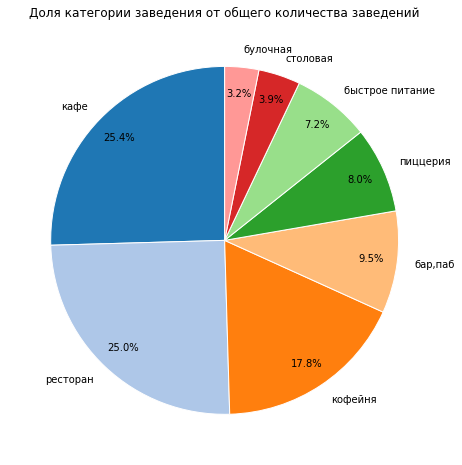

In [28]:
labels = pivot_df_rest.index
sizes = pivot_df_rest['Количество']
colors = plt.cm.get_cmap('tab20').colors[:len(labels)]
plt.figure(figsize=(8, 8))
plt.pie(sizes, 
        labels=labels, 
        colors=colors, 
        autopct='%1.1f%%',
        startangle=90, 
        pctdistance=0.85,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1})
plt.title("Доля категории заведения от общего количества заведений")
plt.show()

*Большая часть заведений относится к категориям `кафе` (25.45%), `ресторан` (25.02%) и `кофейня` (17.76%)*

---

### Задача 2. Анализ заведений по административным районам Москвы


*Изучим распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы.*

*Для начала посмотрим, на какие административные районы делится Москва:*

In [29]:
unique_names = df_rest['district'].unique()
display(unique_names)

array(['северный административный округ',
       'северо-восточный административный округ',
       'северо-западный административный округ',
       'западный административный округ',
       'центральный административный округ',
       'восточный административный округ',
       'юго-восточный административный округ',
       'южный административный округ',
       'юго-западный административный округ'], dtype=object)

*Всего данные содержат информацию по 9 категориям заведений общественного питания Москвы.*

*Чтобы исследовать распределение количества заведений по административным районам Москвы, построим линейчатую диаграмму:*

In [30]:
district_count_rest = df_rest['district'].value_counts(normalize=True).sort_values(ascending=True)
district_count_rest = round((district_count_rest * 100), 2)
display(district_count_rest)

северо-западный административный округ      4.69
юго-восточный административный округ        8.00
юго-западный административный округ         8.26
восточный административный округ            9.19
западный административный округ             9.98
южный административный округ               10.51
северо-восточный административный округ    10.54
северный административный округ            10.73
центральный административный округ         28.10
Name: district, dtype: float64

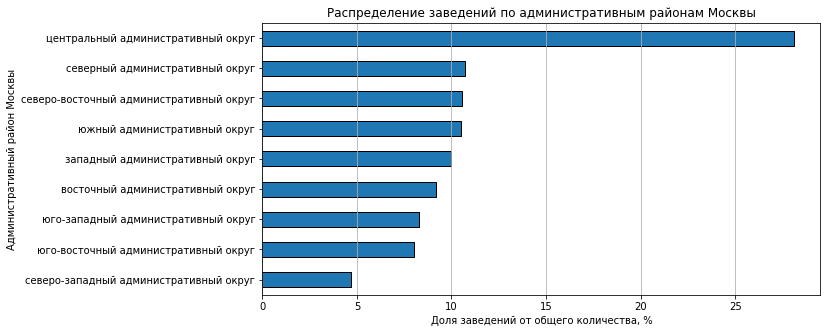

In [31]:
plt.figure(figsize=(10, 5))
district_count_rest.plot(kind='barh', rot=0, legend=False,
               title='Распределение заведений по административным районам Москвы', edgecolor='black')

plt.ylabel('Административный район Москвы')
plt.xlabel('Доля заведений от общего количества, %')
plt.grid(axis='x')
plt.show()

*График наглядно показывает, что наибольшее количество заведений располагается в Центральном административном округе Москвы (28,1% от общего количества заведений)*

*Причинами тому могут быть:*
- *в центре города находится большое количество офисов разных организаций, сотрудники которых ходят на бизнес-ланчи в различные заведения,*
- *в центре любят проводить время как жители города, так и гости столицы.*

*Меньше всего заведений общественного питания в Северо-Западном административном округе (всего 4,69%). Это может быть связано с тем, что в данном районе большое количество природных парков, а также достаточно промзон. Однако по программе "Комплексного развития территорий" данные промзоны постепенно ликвидируют и застраивают новыми жилыми кварталами, что в дальнейшем может увеличить количество точек общепита. Этот фактор можно рассмотреть для определения места открытия нового заведения.*

*В остальных округах относительно друг друга примерно равное количество заведений общественного питания.*

*Теперь изучим распределение количества заведений в Центральном административном округе (ЦАО) по категориям и также построим линейчатую диаграмму:*

In [32]:
cao_rest = df_rest[df_rest['district']=='центральный административный округ']
count_cao_rest = cao_rest.groupby('category')['id'].count()
count_cao_rest = count_cao_rest.sort_values(ascending=True)
total_count_cao = count_cao_rest.sum()
share_cao_rest = round((count_cao_rest * 100 / total_count_cao), 2)
display(share_cao_rest)

category
булочная            2.26
столовая            2.94
быстрое питание     3.84
пиццерия            5.07
бар,паб            16.46
кофейня            19.27
кафе               20.08
ресторан           30.08
Name: id, dtype: float64

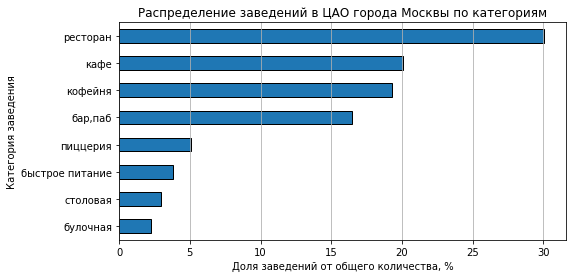

In [33]:
share_cao_rest.plot(kind='barh',
                   figsize=(8, 4),
                   x='category',
                   y='count',
                   legend=False,
                   title='Распределение заведений в ЦАО города Москвы по категориям',  edgecolor='black')

plt.ylabel('Категория заведения')
plt.xlabel('Доля заведений от общего количества, %')
plt.grid(axis='x')
plt.show()


*На графике видно, что основную долю заведений общественного питания занимают рестораны (30.08 % от общего количества заведений в ЦАО). Чуть меньше - кафе и кофейни (20.08 %  и 19.27 % соответственно). Также популярностью пользуются бары/пабы (16.46 %). Меньше всего заведений общественного питания в категории "булочная" (всего 2.26 %).*

---

### Задача 3. Анализ сетевых и несетевых заведений


*Теперь изучим соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения.*

*Для начала сравним общее количество сетевых и несетевых заведений общественного питания между собой, где 0 - несетевое заведение, 1 - сетевое заведение. Построим круговую диаграмму:*

In [34]:
chain_stats = df_rest['chain'].value_counts()
display(chain_stats)

0    4780
1    3087
Name: chain, dtype: int64

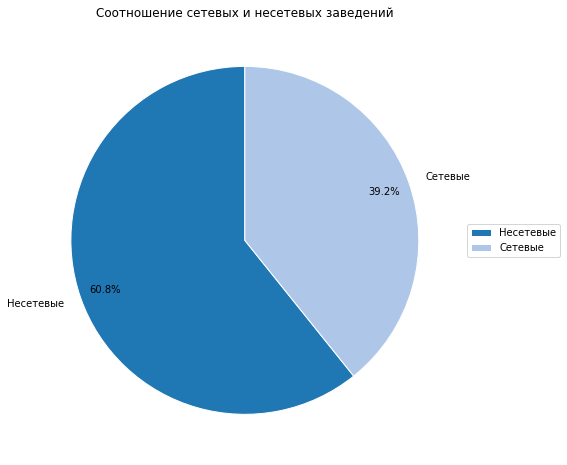

In [35]:
labels = chain_stats.index
sizes = chain_stats.values
colors = plt.cm.get_cmap('tab20').colors[:len(labels)]
custom_labels = ['Несетевые', 'Сетевые']
plt.figure(figsize=(8, 8))
plt.pie(sizes, 
        labels=custom_labels, 
        colors=colors, 
        autopct='%1.1f%%',
        startangle=90, 
        pctdistance=0.85, 
        wedgeprops={'edgecolor': 'white', 'linewidth': 1})
plt.legend(custom_labels, loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.title("Соотношение сетевых и несетевых заведений")
plt.show()

*Несетевых заведений общественного питания гораздо больше, чем сетевых (60.7 % несетевых и 39.3 % сетевых заведений). Сетевых заведений меньше. Это можно объяснить тем, что многие заведения стараются предлагать свою уникальную концепцию, чтобы выделяться среди других и не следовать шаблонному меню сети.*

*Теперь рассмотрим соотношение сетевых и несетевых заведений в разрезе каждой категории заведений общественного питания. Построим линейчатую диаграмму с отображением данных по сетевым и несетевым заведениям:*

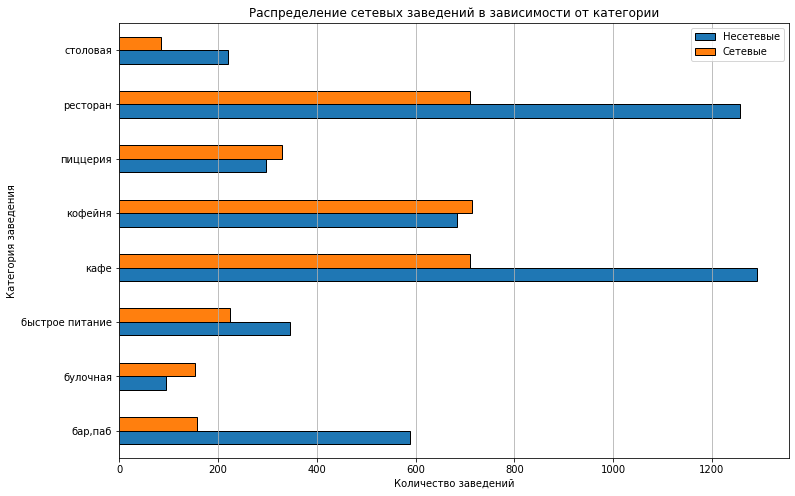

In [36]:
category_chain = df_rest.groupby('category')['chain'].value_counts().unstack(fill_value=0)
category_chain.plot(kind='barh',
               figsize=(12, 8), edgecolor='black')
plt.title('Распределение сетевых заведений в зависимости от категории')
plt.ylabel('Категория заведения')
plt.xlabel('Количество заведений')
plt.legend(['Несетевые', 'Сетевые'])
plt.xticks(rotation=0)
plt.grid(axis='x')
plt.show()

*Среди пиццерий, кофеен и булочных преобладают сетевые заведения. Такой подход понятен, так как такие заведения ориентированы в основном на средний класс и "известное" название позволит привлечь больше клиентов.*

*А вот столовые, рестораны, кафе, заведения быстрого питания и бары/пабы стараются выделиться своей уникальностью.*

---

### Задача 4. Исследование количества посадочных мест в заведениях на предмет аномальных значений или выбросов.


*Прежде чем исследовать количество посадочных мест в заведениях, получим краткое статистическое описание количества посадочных мест в заведениях общественного питания:*

In [37]:
display(df_rest['seats'].describe())

count    4493.000000
mean      107.818607
std       119.221227
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

*Визуализируем полученный результат. Построим гистограмму и диаграмму размаха:*

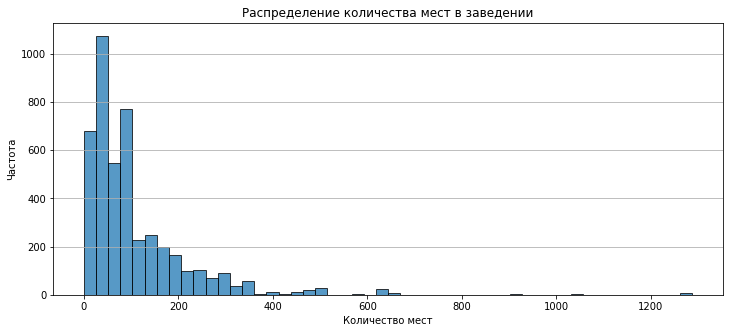

In [38]:
plt.figure(figsize=(12, 5))
df_rest['seats'].plot(kind='hist',
                               bins=50,
                               alpha=0.75,
                               edgecolor='black',
                               rot=0)
plt.title('Распределение количества мест в заведении')
plt.xlabel('Количество мест')
plt.ylabel('Частота')
plt.grid(axis='y')
plt.show()

*Распределение данных действительно выглядит нормальным, однако характеризуется широким разбросом и «хвостом» в правой части гистограммы. Такие высокие значения можно отнести к выбросам. Дополнительно построим диаграмму размаха:*

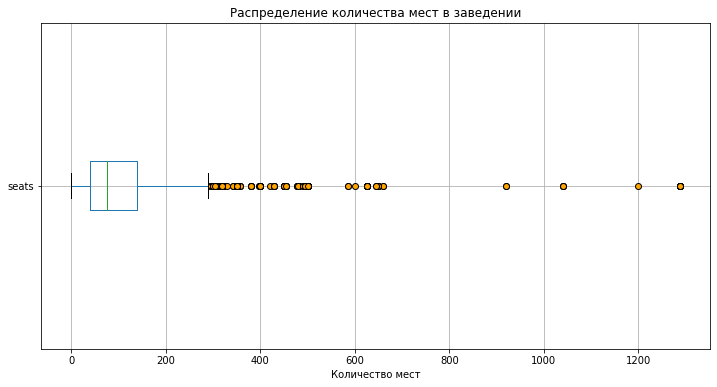

In [39]:
plt.figure(figsize=(12, 6))

df_rest.boxplot(column='seats', vert=False, flierprops=dict(markerfacecolor='orange', marker='o'))
plt.title('Распределение количества мест в заведении')
plt.xlabel('Количество мест')
plt.show()

*Очевидно, что в некоторых заведениях имеются аномальные значения по количеству мест. Встречаются такие заведения, у которых количество мест больше 300. Такие значения можно объяснить либо ошибкой в данных (вероятно данные вносились вручную и некоторые цифры продублировались), либо заведения специфические (например, ресторан может быть банкетным залом на большое количество посадочных мест, а заведения быстрого питания располагаются в крупных фудмоллах или на фут-кортах)*

*Найдем типичное количество посадочных мест для каждой категории заведения общественного питания:*

In [40]:
typical_seats = df_rest.groupby('category')['seats'].median().sort_values()
display("Типичное количество мест (медиана):")
display(typical_seats)

'Типичное количество мест (медиана):'

category
булочная           50.0
пиццерия           55.0
кафе               60.0
быстрое питание    69.5
столовая           73.5
кофейня            80.0
бар,паб            82.0
ресторан           86.0
Name: seats, dtype: float64

*Визуализируем полученный результат. Построим линейчатую диаграмму:*

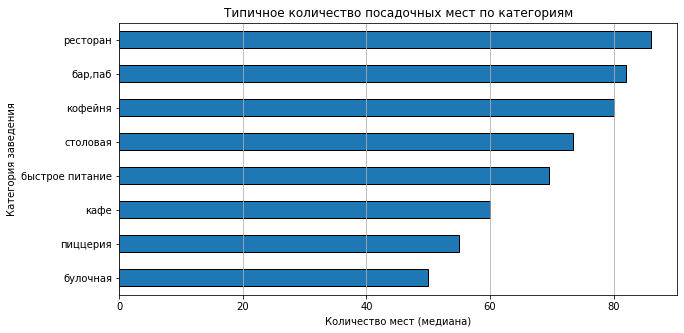

In [41]:
plt.figure(figsize=(10, 5))
typical_seats.plot(kind='barh', edgecolor='black')
plt.title('Типичное количество посадочных мест по категориям')
plt.ylabel('Категория заведения')
plt.xlabel('Количество мест (медиана)')
plt.xticks(rotation=0)
plt.grid(axis='x')
plt.show()

*Наиболее типичное количество мест в заведениях колеблется от 50 (в столовых) до 86 (в ресторанах), что отличается от среднего количества мест. Очевидно, что аномальные значения сильно искажают данные о среднем количестве мест в заведениях всех категорий.*

---

### Задача 5. Влияет ли категория заведения на рейтинг?


*Теперь исследуем, влияет ли категория заведения на его рейтинг. Для начала найдем среднее значение рейтинга заведения по каждой категории:*

In [42]:
avg_ratings = df_rest.groupby('category')['rating'].mean().sort_values(ascending=True)
display(avg_ratings)

category
быстрое питание    4.058947
кафе               4.150799
столовая           4.217320
кофейня            4.275036
булочная           4.276707
ресторан           4.296189
пиццерия           4.301433
бар,паб            4.394504
Name: rating, dtype: float64

*Визуализируем полученные результаты. Построим линейчатую диаграмму:*

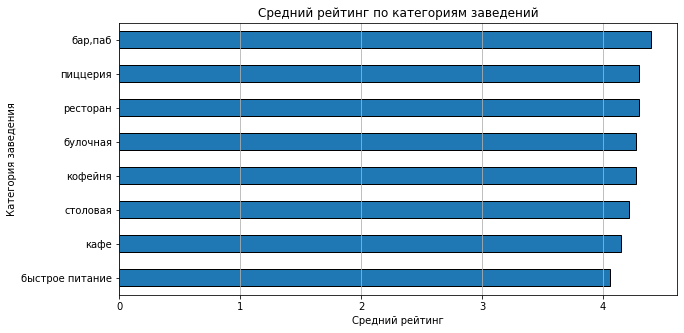

In [43]:
plt.figure(figsize=(10, 5))
avg_ratings.plot(kind='barh', edgecolor='black')
plt.title('Средний рейтинг по категориям заведений')
plt.ylabel('Категория заведения')
plt.xlabel('Средний рейтинг')
plt.xticks(rotation=0)
plt.grid(axis='x')
plt.show()

*Как видно на графике усреднённые рейтинги разных категорий общепита различаются несильно. Средний рейтинг у "лидера" среди категорий заведений (бар/паб) - 4.4, а у "аутсайдера" (рестораны быстрого питания) - 4.06. Вывод: категория заведения на рейтинг влияет слабо.*

---

### Задача 6. Исследование взаимосвязи рейтинга с другими данными.


*Чтобы проверить, как влияют на рейтинг остальные данные из нашего датафрейма построим матрицу корелляции:*

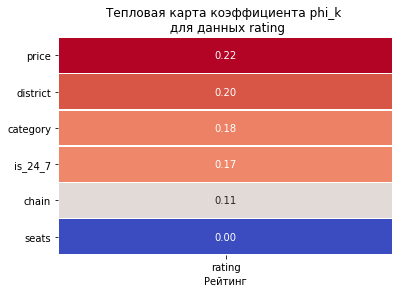

In [44]:
corr_matrix = df_rest[['district', 'category', 'is_24_7', 'rating',
                        'chain', 'price', 'seats']].phik_matrix(interval_cols=['rating', 'chain', 'seats'])
df_heatmap = corr_matrix.loc[corr_matrix.index !='rating'][['rating']].sort_values(by='rating', 
                                                                                                 ascending=False)
sns.heatmap(df_heatmap, annot=True, fmt='.2f', cmap='coolwarm', cbar=False, linewidths=0.5)

plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
plt.xlabel('Рейтинг')
plt.show()

*Матрица корреляции показывает слабую положительную связь рейтинга почти со всеми данными в датафрейме. Так категория цен, район, категория заведения, режим работы и принадлежность к какой-либо сети очень мало влияют на рейтинг заведения. А вот количество мест и средняя стоимость чашки кофе на рейтинг не влияют вообще.*

*Рассмотрим самую "сильную" взаимосвязь рейтинга с данными о ценовой категории заведения. Построим Столбчатую диаграмму для оценки взаимосвязи и проведем линию, которая будет показывать среднее значение:*

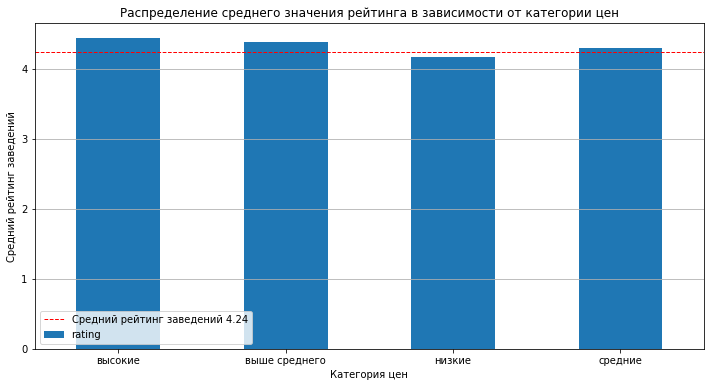

In [45]:
grouped = df_rest.groupby('price')['rating'].mean()
grouped.plot(kind='bar',
               title=f'Распределение cреднего значения рейтинга в зависимости от категории цен',
               legend=True,
               ylabel='Средний рейтинг заведений',
               xlabel='Категория цен',
               rot=0,
               figsize=(12, 6))

# Рассчитываем среднее значение по доле нелояльных клиентов
mean_rating_share = df_rest['rating'].mean()

# Наносим на график линию с средним значением доли нелояльных клиентов
plt.axhline(mean_rating_share, # Данные, по которым строится линия
            color='red', # Цвет линии
            linestyle='--', # Стиль линии
            linewidth=1, # Ширина линии
            label=f'Средний рейтинг заведений {round(mean_rating_share,2)}')

plt.grid(axis='y')
plt.legend()

# Выводим график
plt.show()

*Очевидно, что категория цены заведения очень мало влияет на рейтинг этого заведения. Так можно заметить, что средний рейтинг чуть ниже, если категория цен - "низкие", и наоборот рейтинг совсем немного растет, если "растет" категория цены*

---

### Задача 7.Исследуем топ-15 сетевых заведений Москвы.


*Для того, чтобы исследовать топ-15 самых популярных сетей заведений общественного питания, сначала отберем из датафрейма `df_rest` только те заведения, которые принадлежат какой-либо сети:*

In [46]:
df_chain1 = df_rest.loc[df_rest['chain'] == 1]
filtered_df_chain1 = df_chain1.loc[:][['id', 'name', 'category', 'rating']]
display(filtered_df_chain1.head())

,id,name,category,rating
4,a163aada139c4c7f87b0b1c0b466a50f,иль марко,пиццерия,5.0
13,aea18265b0a0415893f1e796b82568fe,буханка,булочная,4.8
19,feec6bedccae44cb877d99c13f9aa5d7,пекарня,булочная,4.4
20,1ab5691e4da844d3abadf085e0957852,чебуреки манты,кафе,4.3
23,78709462f2b3480f825489a5321a3563,буханка,булочная,4.7


*Теперь сосредоточим внимание именно на анализе сетевых заведений. Для начала выведем топ-15 сетей по их количеству в Москве, а также посчитаем их количество, средний рейтинг и определим категорию, к которой они относятся:*

In [47]:
rest_count = filtered_df_chain1.groupby('name')['id'].count()
top_15_rest = rest_count.sort_values(ascending=True).tail(15)
avg_ratings = round((filtered_df_chain1.groupby('name')['rating'].mean()), 2)
rest_rating = pd.merge(top_15_rest, avg_ratings, on='name')
rest_rating = rest_rating.rename(columns={'id': 'count', 'rating': 'average_rating'})
categories = df_chain1.drop_duplicates('name')[['name', 'category']]
rest_categories = pd.merge(rest_rating, categories, on='name')
count_categories = rest_categories.groupby('category')['name'].count()
count_categories = count_categories.sort_values(ascending=True)
display(rest_categories)

,name,count,average_rating,category
0,му-му,27,4.23,кафе
1,чайхана,29,3.96,кафе
2,буханка,31,4.40,булочная
3,cofefest,32,3.98,кофейня
4,теремок,38,4.12,ресторан
5,хинкальная,39,4.37,кафе
6,кулинарная лавка братьев караваевых,39,4.39,кафе
7,кофепорт,42,4.15,кофейня
8,prime,50,4.12,ресторан
9,cofix,65,4.08,кофейня


*Визуализируем результат. Построим линейчатую диаграмму:*

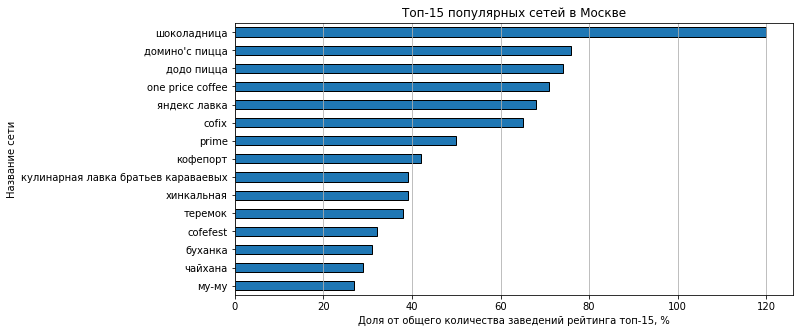

In [48]:
plt.figure(figsize=(10, 5))
top_15_rest.plot(kind='barh', edgecolor='black')
plt.title('Топ-15 популярных сетей в Москве')
plt.ylabel('Название сети')
plt.xlabel('Доля от общего количества заведений рейтинга топ-15, %')
plt.xticks(rotation=0)
plt.grid(axis='x')
plt.show()

*Самой популярной сетью стала кофейня "Шоколадница" (Всего таких заведений в рейтинге 120). Среди популярные сетей также есть такие, как пиццерия "Додо Пицца", пиццерия "Домино'с", кофейня "One Price Coffee", кафе "Лавка братьев Караваевых" и другие. Замыкает рейтинг кафе "Му-Му" (27 заведение по Москве).*

*Отобразим средний рейтинг ТОП-15 сетевых заведений. Построим линейчатую диаграмму:*

<Figure size 720x360 with 0 Axes>

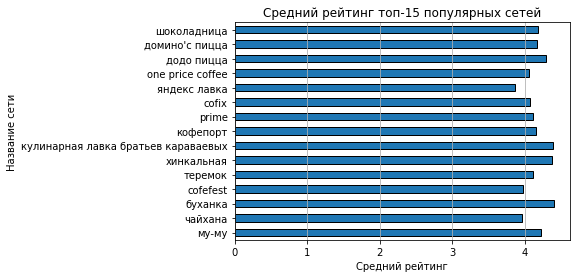

In [49]:
plt.figure(figsize=(10, 5))
rest_rating.reset_index().plot(kind='barh', x='name', y='average_rating', edgecolor='black', legend=False)
plt.title('Средний рейтинг топ-15 популярных сетей')
plt.xlabel('Средний рейтинг')
plt.ylabel('Название сети')
plt.xticks(rotation=0)
plt.grid(axis='x')
plt.show()

*Самый высокий средний рейтинг оказался у булочной "Буханка" (среднее значение 4.4), самый низкий у ресторана "Яндекс Лавка" (среднее значение 3.87). Как видно на графике разбег среднего рейтинга у топ-15 сетевых заведений небольшой и явных "лидеров" среди них нет.*

*Визуализируем распределение категорий среди ТОП-15 сетей. Построим линейчатую диаграмму:*

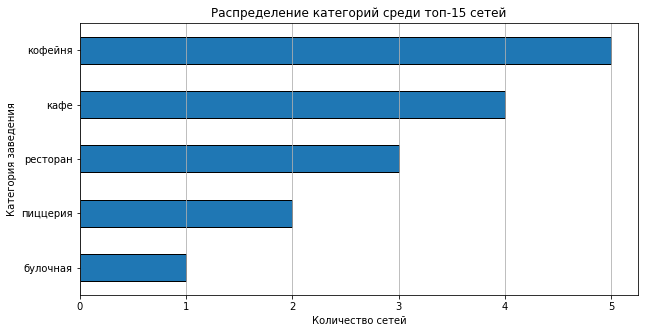

In [50]:
plt.figure(figsize=(10, 5))
count_categories.plot(kind='barh', edgecolor='black', legend=False)
plt.title('Распределение категорий среди топ-15 сетей')
plt.xlabel('Количество сетей')
plt.ylabel('Категория заведения')
plt.xticks(rotation=0)
plt.grid(axis='x')
plt.show()

*Очевидно, что в топ-15 сетей Москвы лидируют кофейни (из всех заведений рейтинга 5 оказались кофейнями), на втором месте идут кафе (4 заведения в этой категории), далее идут рестораны (3 заведения в этой категории) и пиццерии (2 заведения в этой категории), а вот среди топ-15 булочная оказалась всего одна (хотя имеет при этом самый высокий средний рейтинг).*

---

### Задача 8. Вариация среднего чека заведения в зависимости от района. 


*Прежде чем исследовать вариацию среднего чека заведения в зависимости от района Москвы, получим краткое статистическое описание данных по среднему чеку в каждом районе:*

In [51]:
display(df_rest.groupby('district')['middle_avg_bill'].describe())

,count,mean,std,min,25%,50%,75%,max
district,,,,,,,,
восточный административный округ,260.0,820.626923,850.903310,50.0,338.00,575.0,1100.0,10000.0
западный административный округ,305.0,1053.072131,780.284122,50.0,425.00,1000.0,1500.0,5250.0
северный административный округ,322.0,927.959627,912.609221,130.0,350.00,650.0,1250.0,11000.0
северо-восточный административный округ,301.0,716.611296,591.232153,50.0,325.00,500.0,950.0,4500.0
северо-западный административный округ,157.0,822.222930,595.055218,120.0,340.00,700.0,1100.0,2900.0
центральный административный округ,1057.0,1190.559130,921.153865,0.0,500.00,1000.0,1500.0,7250.0
юго-восточный административный округ,194.0,654.097938,566.825663,30.0,281.25,450.0,887.5,3750.0
юго-западный административный округ,235.0,792.561702,559.173122,100.0,350.00,600.0,1100.0,2750.0
южный административный округ,312.0,836.301282,2014.875273,100.0,350.00,500.0,1062.5,35000.0


*Визуализируем вариацию. Построим гистограмму:*

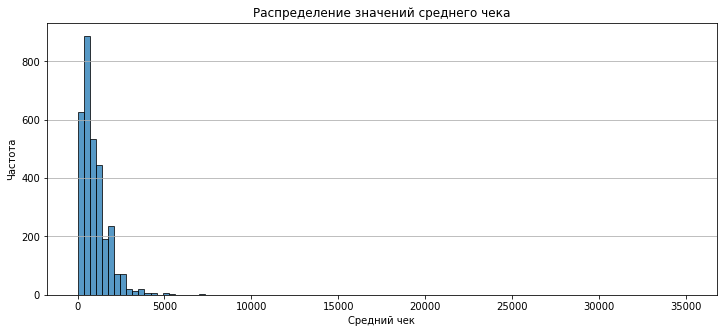

In [52]:
plt.figure(figsize=(12, 5))
df_rest['middle_avg_bill'].plot(kind='hist',
                               bins=100,
                               alpha=0.75,
                               edgecolor='black',
                                rot=0)
plt.title('Распределение значений среднего чека')
plt.xlabel('Средний чек')
plt.ylabel('Частота')
plt.grid(axis='y')
plt.show()

*Распределение данных действительно выглядит нормальным с «хвостом» в правой части гистограммы. Отобразим, аномальные значения. Дополнительно построим диаграмму размаха:*

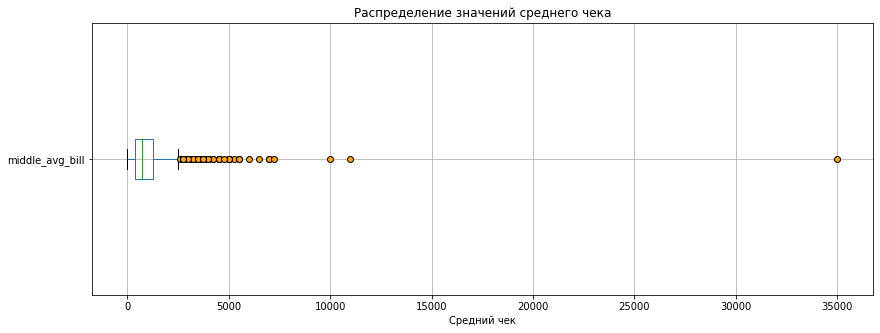

In [53]:
plt.figure(figsize=(14, 5))

df_rest.boxplot(column='middle_avg_bill', vert=False, flierprops=dict(markerfacecolor='orange', marker='o'))
plt.title('Распределение значений среднего чека')
plt.xlabel('Средний чек')
plt.show()

*Большую группу точек, находящихся за правым "усом" не совсем верно называть выбросом. Вероятно, заведение имеет достаточно высокий средний чек. Аномальное значение наблюдается у одного заведения со средним чеком 35 000 руб. Ошибка это, или действительно заведение настолько дорогое - стоит уточнить непосредственно у представителей данного заведения, после чего определить есть ли в данных ошибка.*

*Теперь исследуем средний чек заведения в зависимости от района Москвы. Построим линейчатую диаграмму:*

In [54]:
district_avg_bill = round(df_rest.groupby('district')['middle_avg_bill'].mean(), 2)
district_avg_bill = district_avg_bill.sort_values(ascending = True)
display(district_avg_bill)

district
юго-восточный административный округ        654.10
северо-восточный административный округ     716.61
юго-западный административный округ         792.56
восточный административный округ            820.63
северо-западный административный округ      822.22
южный административный округ                836.30
северный административный округ             927.96
западный административный округ            1053.07
центральный административный округ         1190.56
Name: middle_avg_bill, dtype: float64

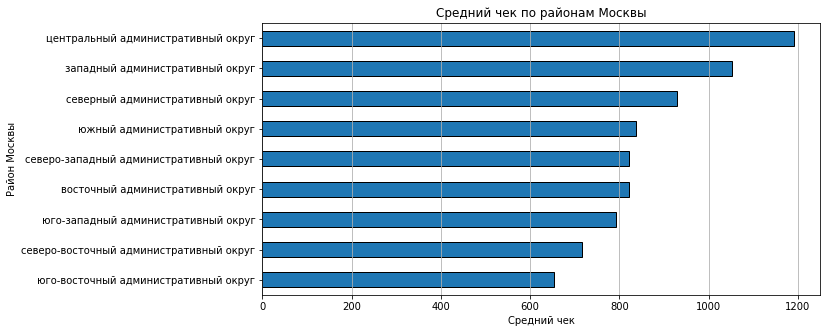

In [55]:
plt.figure(figsize=(10, 5))
district_avg_bill.plot(kind='barh', edgecolor='black')
plt.title('Средний чек по районам Москвы')
plt.ylabel('Район Москвы')
plt.xlabel('Средний чек')
plt.grid(axis='x')
plt.show()


*Как и ожидалось, самый высокий средний чек в заведениях, которые находятся в Центральном административном округе (средний чек здесь составляет 1190,56 руб). Здесь сосредоточены основные достопримечательности, главные офисы многих крупных компаний и поток клиентов достаточно большой. Самый низкий средний чек в СВАО (716,61 руб) и ЮВАО (654,10 руб.). Это можно объяснить тем, здесь располагаются непрестижные спальные районы Москвы, а также много промышленных производств, где работают и живут преимущественно "средний класс" населения.*

---

### Промежуточный вывод


*Проведя исследовательский анализ заведений общественного питания можно сделать некоторые выводы:*

- *большая доля заведений Москвы относится к таким категориям, как кафе, ресторан и кофейня;*
- *наибольшее количество заведений располагается в Центральном административном округе Москвы, основная масса из них - рестораны;*
- *несетевых заведений гораздо больше, чем сетевых;*
- *наиболее типичное количество мест колеблется от 50 до 86;*
- *категория заведений слабо влияет на рейтинг этого заведения;*
- *а вот средний чек заведения оказывает на рейтинг большее влияние (заведения с более высоким средним чеком имеют достаточно высокий рейтинг);*
- *среди топ-15 сетевых заведений больше всего кофеен (5 из 15), при этом средний рейтинг приблизительно одинаков у всех категорий заведений общественного питания*
- *средний чек в заведениях, находящихся в центре Москвы самый высокий. Немного ниже средний чек на западе и севере Москвы. А дешевле всего поесть получится в заведениях на юго-востоке Москвы.* 

## 4. Итоговый вывод и рекомендации


**1. Общий обзор проделанной работы.**

*В ходе исследования были проанализированы данные с заведениями общественного питания Москвы, составленные на основе данных сервисов Яндекс Карты и Яндекс Бизнес на лето 2022 года. Данные включали в себя информацию о названиях заведений общественного питания, их категорию, район, где они располагались, принадлежность к какой-либо сети, а также данные о режиме работы и среднем чеке.*

*В результате предобработки была проверена корректность данных, изучены пропущенные значения, удалены дубликаты, а также был добавлен новый столбец с указанием является ли заведение круглосуточным или нет.*

*Далее был выполнен сам исследовательский анализ, в ходе которого были даны ответы на вопросы инвесторов фонда "Shut Up and Take My Money".*

**2. Ответы на исследовательские вопросы, или главные выводы.**

*В данных присутствуют такие категории общепита, как: кафе, ресторан, кофейня, пиццерия, бар/паб, быстрое питание, булочная, столовая. Большая часть заведений относится к категориям кафе (25.45%), ресторан (25.02%) и кофейня (17.76%).*

*Заведения в данных располагаются в 9 администранивных районах Москвы. Больше всего их в Центральном административном районе (2211 заведений), а меньше всего в Северо-Западном административном районе (369 заведений). Если рассматривать заведения в ЦАО, то здесь преобладают рестораны (665 заведений).*

*Несетевых заведений в представленных данных гораздо больше, чем сетевых (4781 несетевых и 3089 сетевых заведений). Среди пиццерий, кофеен и булочных преобладают сетевые заведения, а  рестораны, кафе, бары/пабы, заведения быстрого питания и столовые стараются не принадлежать какой-либо сети.*

*В ходе исследования количество посадочных мест были обнаружены аномальные значения. Так некоторые заведения не указали количество мест, поэтому в данных среди минимальных значений присутствует 0, а в отдельных заведениях количество мест сильно превышает типичные значения (от 50 мест в столовых до 86 в ресторанах). Так максимальное значение посадочных мест достигло 1288. Вероятно данные могли вноситься вручную и некоторые цифры продублировались, либо заведение является банкетным залом.*

*В ходе исследования выяснилось, что категория заведения на рейтинг влияет слабо. Средний рейтинг у "лидера" среди категорий заведений (бар/паб) - 4.4, а у "аутсайдера" (рестораны быстрого питания) - 4.06. Хорошие и плохие отзывы могут быть в любой категории заведений.*

*А вот взаимосвязь рейтинга и среднего чека в заведении оказалась достаточно сильной. В ходе исследования выяснилось, что заведения с более высоким средним чеком (от 5 000 руб.) имеют рейтинг от 4.0 до 5.0*

*Далее более детально были изучены данные сетевых заведений и составлен рейтинг топ-15 по количеству заведений сети. Самой популярной сетью стала кофейня "Шоколадница" (120 заведений в Москве). Среди популярные сетей также есть такие, как пиццерия "Додо Пицца", пиццерия "Домино'с", кофейня "One Price Coffee", кафе "Лавка братьев Караваевых" и другие. Замыкает рейтинг булочная "Буханка" (31 заведение по Москве). При этом средний рейтинг этих заведений колеблется от 3.87 (ресторан "Яндекс Лавка) до 4.4 (булочная "Буханка").*

*В топ-15 сетей Москвы лидируют кофейни (из всех заведений рейтинга 5 оказались кофейнями), на втором месте идут рестораны (3 заведения в этой категории), далее идут пиццерии и кафе (по 2 заведения в каждой категории), а вот среди топ-15 булочная оказалась всего одна (хотя имеет при этом самый высокий средний рейтинг)*


*Последним пунктом анализа стало исследование вариации среднего чека заведения в зависимости от района. Выяснилось, что район достаточно сильно влияет на средний чек в заведении. Так в ЦАО средний чек в заведении составил 1190,56 руб), что является самым высоким значением, а дешевле всего поесть можно в СВАО (716,61 руб) и ЮВАО (654,10 руб.).*

**3. Рекомендации на основе анализа данных.**

*Данный исследовательский анализ был проведен с целью определения категории нового заведения и подходящего места для открытия нового заведения.*

*Рекомендации для инвесторов фонда "Shut Up and Take My Money":*

*Для открытия нового заведения стоит рассмотреть районы ближе к окраине Москвы (например, Северо-западный административный округ, где меньше всего заведений). Здесь не так много заведений общественного питания, но при этом средний чек в заведении не настолько низкий, как, например, в ЮВАО. Можно провести более детальный анализ данного района и выяснить, количество заведений в каждой категории здесь располагается. Это поможет определить заведение какого направления с большей долей вероятности принесут прибыль.*